In [ ]:
import sys
from pathlib import Path

# add v1.1/ to sys.path for imports to work
sys.path.append(str(Path("..").resolve()))  # if notebook is in notebooks/

# import utils
import modules.yaml_utils as yu
import modules.graph as g
import modules.factory as f
import modules.planner as p

# important paths

ROOT = Path("..").resolve()
FILES = ROOT / "files"
INPUTS = FILES / "inputs"
GENERATED = FILES / "generated"


In [28]:
def all_initial_boxes():
    boxtypes = [f.EMPTY, f.TYPE_A, f.TYPE_B, f.TYPE_C]
    initial_boxes = []
    for b1 in boxtypes:
        for b2 in boxtypes:
            for b3 in boxtypes:
                for b4 in boxtypes:
                    initial_boxes.append((b1, b2, b3, b4))
    return initial_boxes

def test_all_initial_states(graph_dict, factory_components_dict, methods = ["astar", "closest"]):
    planner = p.Planner(graph_dict, factory_components_dict)
    initial_boxes = all_initial_boxes()
    total_cost = {}
    total_cost["boxes"] = initial_boxes
    for method in methods:
        planner.method = method
        total_cost[method] = []
        for i_boxes in initial_boxes:
            _, _, _, tot_cost = planner.plan_initial(i_boxes)
            total_cost[method].append(round(tot_cost, 3))

    rows = list(zip(total_cost["astar"], total_cost["closest"], total_cost["boxes"]))
    rows = sorted(rows)
    N = len(total_cost["astar"])

    total_cost["astar"] = [rows[i][0] for i in range(N)]
    total_cost["closest"] = [rows[i][1] for i in range(N)]
    total_cost["boxes"] = [rows[i][2] for i in range(N)]
    return total_cost
            
    

In [29]:
graph_yaml = INPUTS / "graph.yaml"
components_yaml = INPUTS / "factory_components.yaml"

graph_dict = yu.load_file(graph_yaml)
components_dict = yu.load_file(components_yaml)

total_cost = test_all_initial_states(graph_dict, components_dict)

closest: [7.593, 7.637, 8.755, 7.699, 8.861, 8.755, 8.755, 7.999, 8.861, 8.149, 8.149, 8.149, 8.237, 8.237, 9.461, 8.419, 8.525, 8.537, 9.355, 9.461]
astar: [7.593, 7.637, 7.637, 7.699, 7.743, 7.937, 7.937, 7.999, 8.043, 8.149, 8.149, 8.149, 8.237, 8.237, 8.343, 8.419, 8.525, 8.537, 8.537, 8.643]


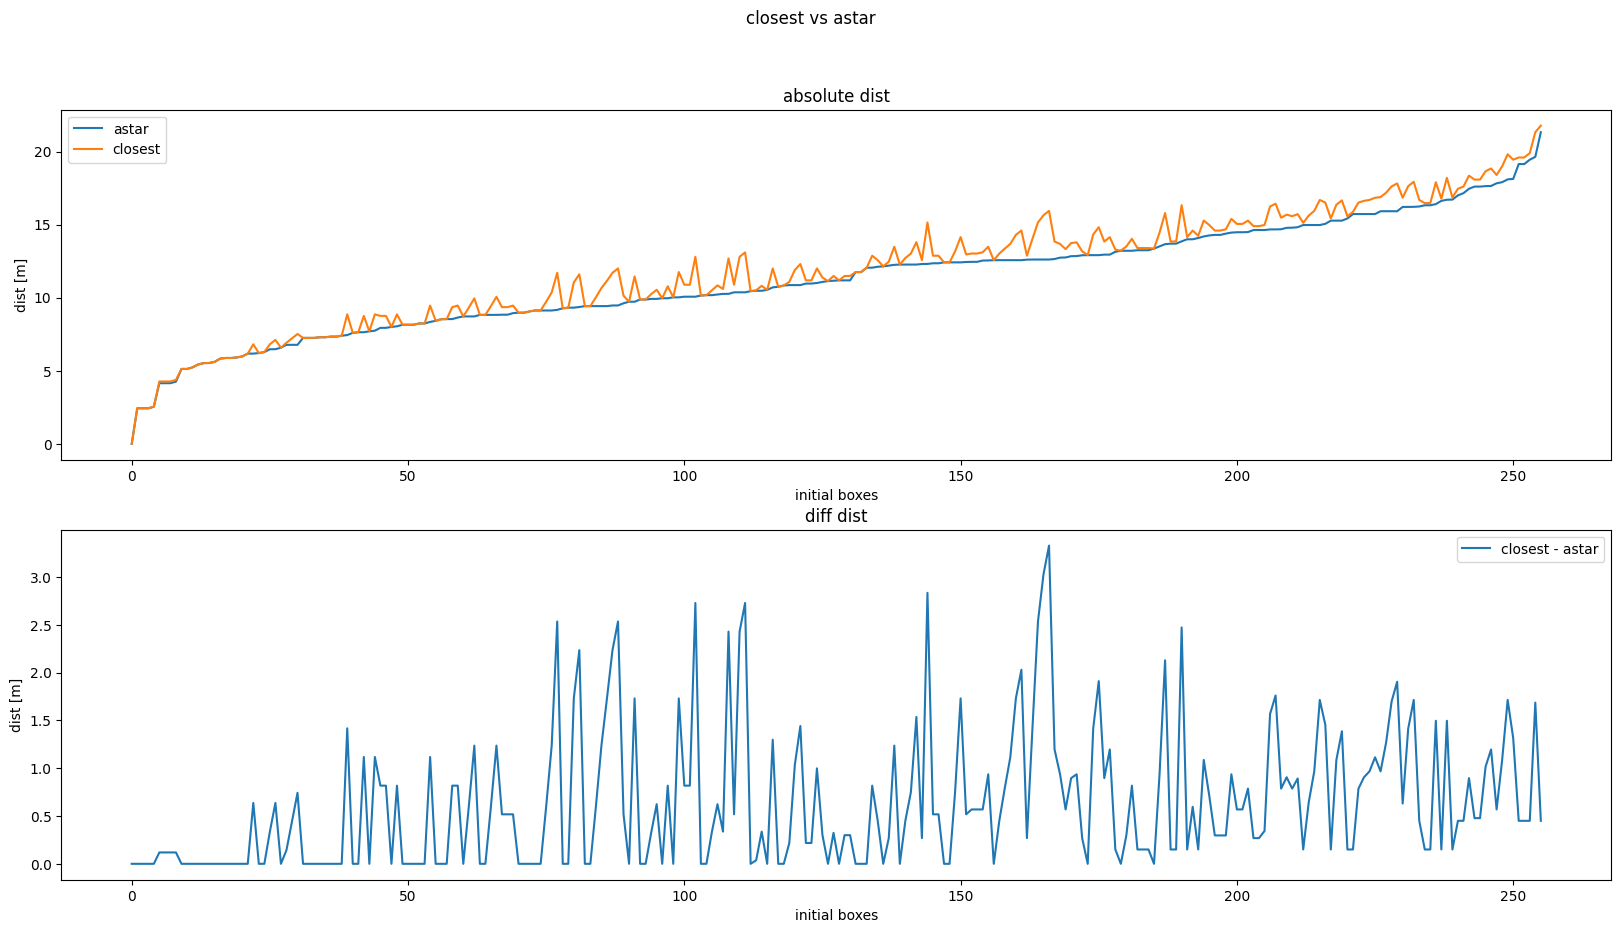

In [37]:
import matplotlib.pyplot as plt


fig, axs = plt.subplots(2, 1, figsize=(20, 10))
fig.suptitle("closest vs astar")
ax = axs[0]
ax.set_title("absolute dist")
ax.plot(total_cost["astar"], label="astar")
ax.plot(total_cost["closest"], label="closest")
ax.set_xlabel("initial boxes")
ax.set_ylabel("dist [m]")
ax.legend()

diff = [total_cost["closest"][i] - total_cost["astar"][i] for i in range(len(total_cost["astar"]))]

ax = axs[1]
ax.set_title("diff dist")
ax.plot(diff, label="closest - astar")
ax.set_xlabel("initial boxes")
ax.set_ylabel("dist [m]")
ax.legend()

print(f"closest: {total_cost['closest'][40:60]}")
print(f"astar: {total_cost['astar'][40:60]}")






In [25]:
a = [1, 2,3 ]
b = [4, 5, 6]
print(list(zip(a, b)))

[(1, 4), (2, 5), (3, 6)]
